# SegModels Google Colab Notebook
This notebook allows you to easily use and test models from the [SegModels](https://github.com/imadalishah/SegModels) repository.

## 1. Setup
Clone the repository and install dependencies.

In [1]:
import os

# Clone the repository
!git clone https://github.com/imadalishah/SegModels.git
%cd SegModels

# Install requirements (if requirements.txt exists)
if os.path.exists('requirements.txt'):
    !pip install -r requirements.txt
else:
    # Default common dependencies for segmentation models
    !pip install torch torchvision torchaudio opencv-python matplotlib albumentations segmentation-models-pytorch

Cloning into 'SegModels'...
remote: Enumerating objects: 196, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (27/27), done.
remote: Total 196 (delta 22), reused 6 (delta 6), pack-reused 161 (from 1)
Receiving objects: 100% (196/196), 75.68 KiB | 1.04 MiB/s, done.
Resolving deltas: 100% (83/83), done.
/content/SegModels
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 33.4 MB/s eta 0:00:00


## 2. Import Modules
Import necessary libraries and project modules.

In [2]:
import torch
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import numpy as np

# Verification
print(f"Using Torch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

Using Torch version: 2.11.0+cu128
CUDA available: True


## 3. Model Initialization and Inference
Here is how you can initialize a model using the `ModelFactory`.

In [3]:
from seg_models.factory import create_segmentation_model
import torch

# Initialize a model (e.g., 'unet')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_name = "unet"

# Create the model using the factory
model = create_segmentation_model(
    model_name=model_name,
    backbone_name="resnet34",
    in_channels=3,
    out_channels=1,
    pretrained=True
)

model.to(device)
model.eval()

# Create a dummy input tensor (Batch, Channels, Height, Width)
dummy_input = torch.randn(1, 3, 224, 224).to(device)

with torch.no_grad():
    output = model(dummy_input)

print(f"Model '{model_name}' initialized successfully.")
print(f"Input shape: {dummy_input.shape}")
print(f"Output shape: {output.shape}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model 'unet' initialized successfully.
Input shape: torch.Size([1, 3, 224, 224])
Output shape: torch.Size([1, 1, 224, 224])


## 4. Training Example
We will use a small sample of the Oxford-IIIT Pet dataset for this demonstration. We'll configure the training for multiple models.

In [4]:
import os

# 1. Download/Setup dataset
if not os.path.exists('images'):
    print("Downloading dataset...")
    !wget -q https://thor.robots.ox.ac.uk/~vgg/data/pets/images.tar.gz
    !wget -q https://thor.robots.ox.ac.uk/~vgg/data/pets/annotations.tar.gz
    !tar -xf images.tar.gz
    !tar -xf annotations.tar.gz

### 4.1 Dataset Preview
Let's visualize a few samples from the dataset. We will show the original image and the mask after it has been converted to a binary (Foreground vs Background) format.

Initializing Dataloaders...
📂 Dataloaders ready — train=5912  val=1478


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


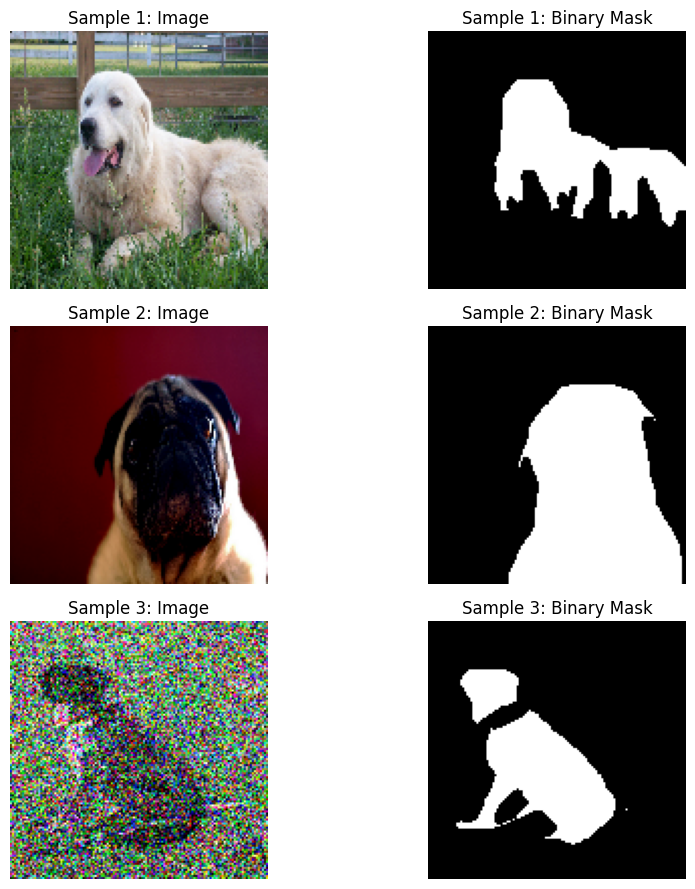

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from seg_models.factory import create_segmentation_model
from seg_models.dataloader import create_dataloaders

def show_dataset_samples(loader, num_samples=3):
    # Ensure a batch
    batch = next(iter(loader))
    imgs = batch['image']
    msks = batch['mask']

    plt.figure(figsize=(10, 3 * num_samples))
    for i in range(num_samples):
        # Original Image
        plt.subplot(num_samples, 2, i*2 + 1)
        img = imgs[i].permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        plt.imshow(img)
        plt.title(f"Sample {i+1}: Image")
        plt.axis('off')

        # Binarized Mask
        plt.subplot(num_samples, 2, i*2 + 2)
        # 1=Foreground, 2=Background, 3=Outline
        binary_mask = (msks[i].squeeze() == 1).numpy()
        plt.imshow(binary_mask, cmap='gray')
        plt.title(f"Sample {i+1}: Binary Mask")
        plt.axis('off')

    plt.tight_layout()
    plt.show()


# 1. Initialize Dataloaders
print("Initializing Dataloaders...")
loaders = create_dataloaders(
    image_dir='images',
    mask_dir='annotations/trimaps',
    batch_size=8,
    img_size=(128, 128),
    num_workers=2
)
train_loader = loaders['train']
val_loader = loaders['val']

if 'train_loader' in globals():
    show_dataset_samples(train_loader)
else:
    print("Please run the initialization/dataloaders.")

In [6]:
# 2. Training Loop
QUICK_CHECK = True  # If True, the model(s) train on 10 Epochs Only

model_names = ['unet', 'fpn']
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
trained_models = {}
epochs = 100 if not QUICK_CHECK else 10

for name in model_names:
    print(f'\n--- Training {name} ---')
    model = create_segmentation_model(name, 'resnet18', in_channels=3, out_channels=1)
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
    criterion = torch.nn.BCEWithLogitsLoss()

    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0
        num_batches = 0
        for i, batch in enumerate(train_loader):
            imgs = batch['image'].to(device)
            msks = batch['mask'].to(device)

            # Binarize: Foreground (1) vs everything else
            binary_masks = (msks == 1).float()
            if binary_masks.ndim == 3:
                binary_masks = binary_masks.unsqueeze(1)

            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, binary_masks)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            num_batches += 1

            # Truncate training for quick checking
            if QUICK_CHECK and i >= 20:
                break

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch}/{epochs} Loss: {epoch_loss/num_batches:.4f}')

    trained_models[name] = model

print('\nMulti-model training complete.')


--- Training unet ---


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

Epoch 1/10 Loss: 0.6807
Epoch 5/10 Loss: 0.3949
Epoch 10/10 Loss: 0.3117

--- Training fpn ---
Epoch 1/10 Loss: 0.9068
Epoch 5/10 Loss: 0.3724
Epoch 10/10 Loss: 0.3334

Multi-model training complete.


## 5. Visualization: Input, Ground Truth, and Prediction

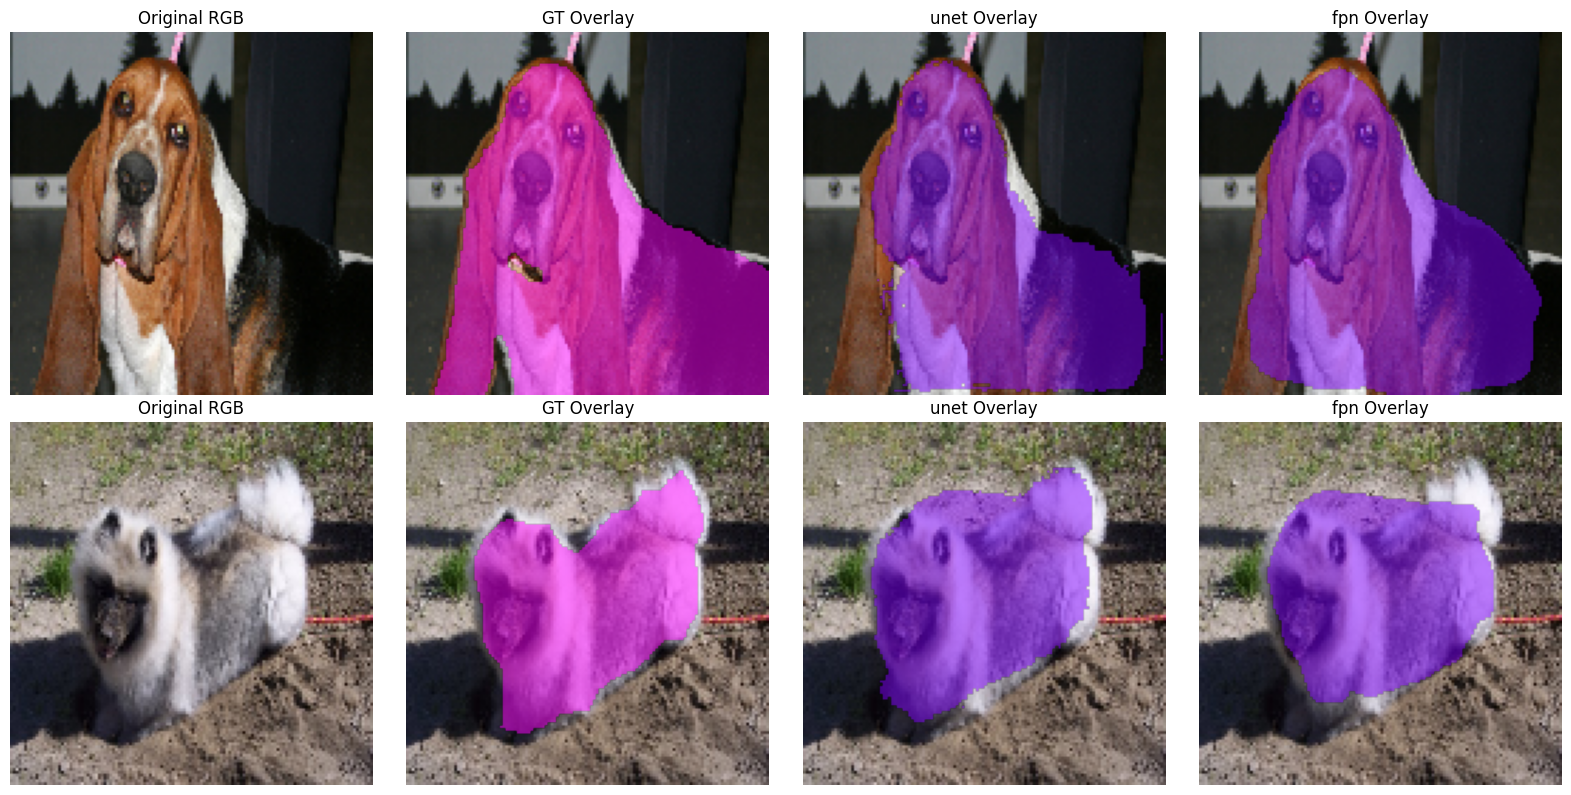

In [7]:
def visualize_comparison(models_dict, loader, device):
    batch = next(iter(loader))
    images = batch['image'].to(device)
    masks = batch['mask'].to(device)

    num_samples = 2
    num_models = len(models_dict)
    # Columns: Original RGB + GT Overlay + (N Models Overlays)
    total_cols = 2 + num_models

    plt.figure(figsize=(4 * total_cols, 4 * num_samples))

    for i in range(num_samples):
        # 1. Original RGB
        plt.subplot(num_samples, total_cols, i * total_cols + 1)
        img = images[i].cpu().permute(1, 2, 0).numpy()
        img = (img - img.min()) / (img.max() - img.min() + 1e-8)
        plt.imshow(img)
        plt.title("Original RGB")
        plt.axis('off')

        # 2. RGB Overlay with Ground Truth
        plt.subplot(num_samples, total_cols, i * total_cols + 2)
        plt.imshow(img)
        gt_binary = (masks[i].cpu().squeeze() == 1).numpy()
        gt_overlay = np.ma.masked_where(gt_binary == 0, gt_binary)
        plt.imshow(gt_overlay, cmap='spring', alpha=0.5)
        plt.title("GT Overlay")
        plt.axis('off')

        # 3. RGB Overlay with Predicted Masks
        for idx, (name, model) in enumerate(models_dict.items()):
            model.eval()
            with torch.no_grad():
                logits = model(images[i:i+1])
                pred = torch.sigmoid(logits).cpu().squeeze().numpy()

            plt.subplot(num_samples, total_cols, i * total_cols + 3 + idx)
            plt.imshow(img)
            # Create mask for prediction (> 0.5 threshold)
            pred_mask = pred > 0.5
            pred_overlay = np.ma.masked_where(pred_mask == 0, pred_mask)
            plt.imshow(pred_overlay, cmap='rainbow', alpha=0.5)
            plt.title(f"{name} Overlay")
            plt.axis('off')

    plt.tight_layout()
    plt.show()

if 'trained_models' in globals() and trained_models:
    visualize_comparison(trained_models, val_loader, device)
else:
    print("Trained models not found.")

## 6. Saving and Loading Models
To use your trained models later or deploy them, you should save the `state_dict`. This is the recommended way to save models in PyTorch.

In [8]:
import torch
import os

# Create a directory for weights
os.makedirs('weights', exist_ok=True)

# 1. Save the models
for name, model in trained_models.items():
    save_path = f'weights/{name}_pet_seg.pth'
    torch.save(model.state_dict(), save_path)
    print(f"Saved {name} weights to {save_path}")

# 2. Example: How to Load
# First, initialize the architecture as before
loaded_model = create_segmentation_model('unet', 'resnet18', in_channels=3, out_channels=1)

# Then, load the state dictionary
weights_path = 'weights/unet_pet_seg.pth'
loaded_model.load_state_dict(torch.load(weights_path, map_location=device))
loaded_model.to(device)
loaded_model.eval()

print("\nModel successfully reloaded from disk.")

Saved unet weights to weights/unet_pet_seg.pth
Saved fpn weights to weights/fpn_pet_seg.pth

Model successfully reloaded from disk.


## 7. Performance Benchmarking
Let's analyze the model complexity (parameters) and inference speed (latency) on different devices.

In [9]:
import time
import torch
import pandas as pd

def benchmark_models(models_dict, loader):
    results = []

    for name, model in models_dict.items():
        model_results = {"MODEL": name.upper()}

        # 1. Parameter Count (Millions)
        total_params = sum(p.numel() for p in model.parameters())
        model_results["Parameters (Million)"] = round(total_params / 1e6, 2)

        # 2. Benchmark on different devices
        for device_name in ['cuda', 'cpu']:
            device_label = device_name.upper()
            if device_name == 'cuda' and not torch.cuda.is_available():
                model_results[f"{device_label} Inference (ms)"] = "N/A"
                model_results[f"{device_label} Throughput (FPS)"] = "N/A"
                continue

            device = torch.device(device_name)
            model.to(device)
            model.eval()

            # Warmup
            dummy = torch.randn(1, 3, 128, 128).to(device)
            for _ in range(5):
                with torch.no_grad():
                    _ = model(dummy)

            start_time = time.time()
            num_images = 0

            with torch.no_grad():
                for batch in loader:
                    imgs = batch['image'].to(device)
                    _ = model(imgs)
                    num_images += imgs.size(0)

            end_time = time.time()
            total_time = end_time - start_time
            avg_latency = (total_time / num_images) * 1000
            fps = num_images / total_time

            model_results[f"{device_label} Inference (ms)"] = round(avg_latency, 2)
            model_results[f"{device_label} Throughput (FPS)"] = round(fps, 2)

        results.append(model_results)

    # Display as Table
    df_results = pd.DataFrame(results)
    display(df_results)

# Run the benchmark
benchmark_models(trained_models, val_loader)

,MODEL,Parameters (Million),CUDA Inference (ms),CUDA Throughput (FPS),CPU Inference (ms),CPU Throughput (FPS)
0,UNET,14.33,4.78,209.02,44.21,22.62
1,FPN,13.05,3.98,251.06,35.21,28.40
